### Today task is to compare the performance of:
	•	A CNN trained from scratch
	•	A model using Transfer Learning (MobileNetV2)

for classifying flower images.



#### After this lab, students will be able to:
	•	Build a CNN model from scratch
	•	Apply transfer learning using a pre-trained network
	•	Compare training accuracy, Precision and Recall
	•	Analyze learning curves
	•	Understand why transfer learning is effective

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | _RACHANA R_     |
| 🆔 **USN**              | _1RUB25CSE0015_           |
| **Section**        | _ |
| **Programme**   | M.Tech             |
| **School**  | Computer Science and Engineering |


### Transfer Learning reuses knowledge learned from large datasets (e.g., ImageNet) to solve new problems efficiently.

#### Key idea:
	•	Early CNN layers learn generic features (edges, textures)
	•	Later layers learn task-specific features
	•	We reuse earlier layers and train only new layers


**Task 01:** Load the important libraries

In [1]:
!pip install opencv-python

import numpy as np
import matplotlib.pyplot as plt
import pathlib
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

**Task 02:** Load Dataset

We use the TensorFlow Flower dataset containing 5 classes.

In [2]:
import tensorflow as tf
from tensorflow import keras
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)

data_dir = pathlib.Path(data_dir)

print("data_dir =", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
data_dir = /root/.keras/datasets/flower_photos


**Task 03:** Data Exploration

In [3]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"
    print("Fixed data_dir =", data_dir)

Fixed data_dir = /root/.keras/datasets/flower_photos/flower_photos


In [4]:
print("Total jpg:", len(list(data_dir.glob("*/*.jpg"))))
print("Class counts:")
for cls in ["roses","daisy","dandelion","sunflowers","tulips"]:
    print(cls, len(list(data_dir.glob(f"{cls}/*.jpg"))))

Total jpg: 3670
Class counts:
roses 641
daisy 633
dandelion 898
sunflowers 699
tulips 799


In [5]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

**Task 04:** — Create Training and Validation Sets

In [6]:
IMG_SIZE = (224,224 )      # Fill
BATCH_SIZE = 32             # Fill
SEED = 128

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.25,
    subset = "training",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split =0.25,
    subset = "validation",
    seed = SEED,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2753 files for training.
Found 3670 files belonging to 5 classes.
Using 917 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


**Task 05:** Visualizing Simple Images for Pre-check

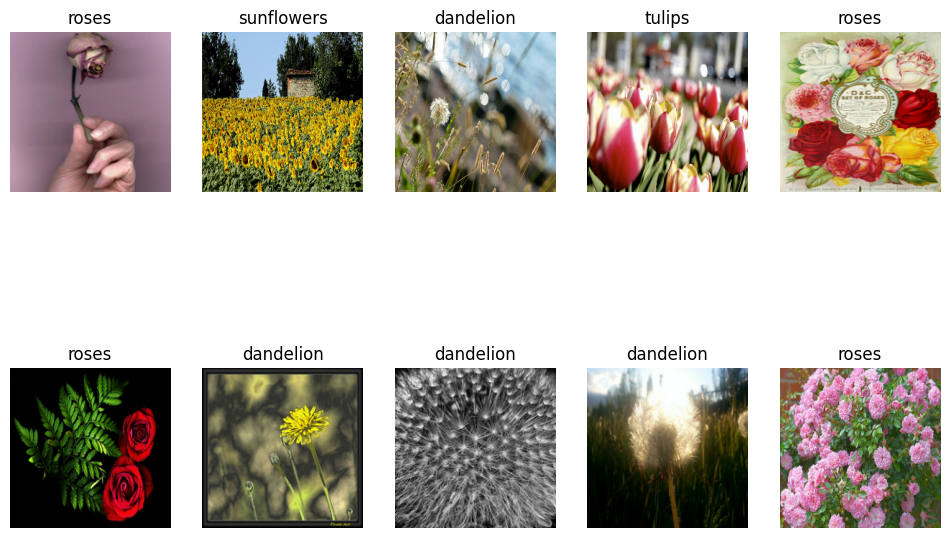

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.show()

**Task 06:** — Optimize Dataset Pipeline

In [8]:
import tensorflow as tf
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

normalizer = layers.Rescaling(1./255)

**Task 07** -- Implement CNN without Transfer Learning

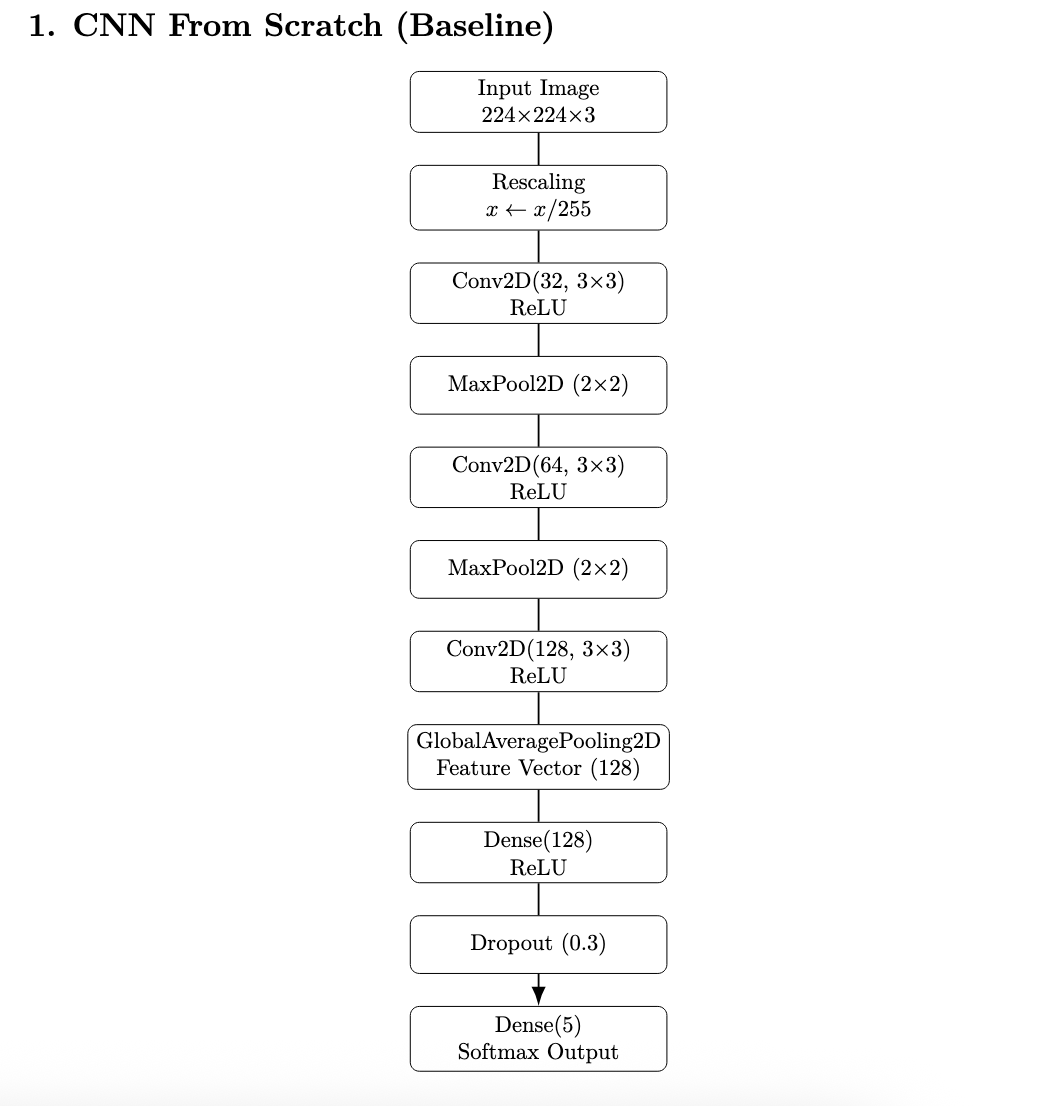

In [9]:
baseline_model = keras.Sequential([

    layers.Input(shape = IMG_SIZE + (3,)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

**Task 08:** Train the baseline model for study

In [10]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.3400 - loss: 1.4502 - val_accuracy: 0.4144 - val_loss: 1.3072
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4501 - loss: 1.2620 - val_accuracy: 0.5049 - val_loss: 1.1880
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4907 - loss: 1.1711 - val_accuracy: 0.5169 - val_loss: 1.1083
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5147 - loss: 1.1604 - val_accuracy: 0.5496 - val_loss: 1.0829
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.5423 - loss: 1.1008 - val_accuracy: 0.5583 - val_loss: 1.1040


Task 09: Implement the CNN with Transfer Learning using MobileVnet Model [ Lightweight ]

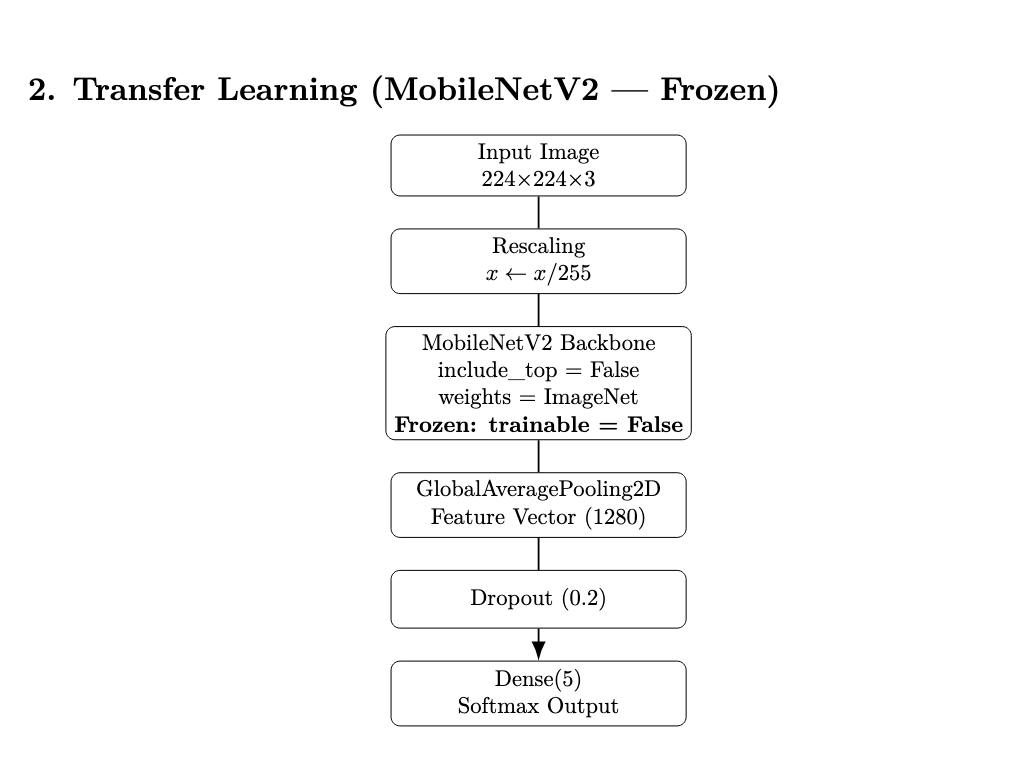

In [14]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = IMG_SIZE + (3,),
    include_top = False,    # Fill
    weights = "imagenet"        # Fill
)

base_model.trainable = False  # Freeze or not?

tl_model = keras.Sequential([
    layers.Input(shape = IMG_SIZE + (3,)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),   # Fill
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
tl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Task 10:** Train the tranfer learning model

In [16]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 51s 380ms/step - accuracy: 0.6698 - loss: 0.8793 - val_accuracy: 0.8092 - val_loss: 0.5199
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8445 - loss: 0.4530 - val_accuracy: 0.8604 - val_loss: 0.4268
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8787 - loss: 0.3588 - val_accuracy: 0.8615 - val_loss: 0.3937
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8936 - loss: 0.3099 - val_accuracy: 0.8735 - val_loss: 0.3844
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9041 - loss: 0.2838 - val_accuracy: 0.8800 - val_loss: 0.3789
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9197 - loss: 0.2442 - val_accuracy: 0.8866 - val_loss: 0.3702
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9237 - loss: 0.2266 - val_accuracy: 0.8877 - val_loss: 0.3696
Epoch 8/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9328 - loss: 0.2008 - val_accuracy: 0.8909 -

#Compare the Learning curves of both

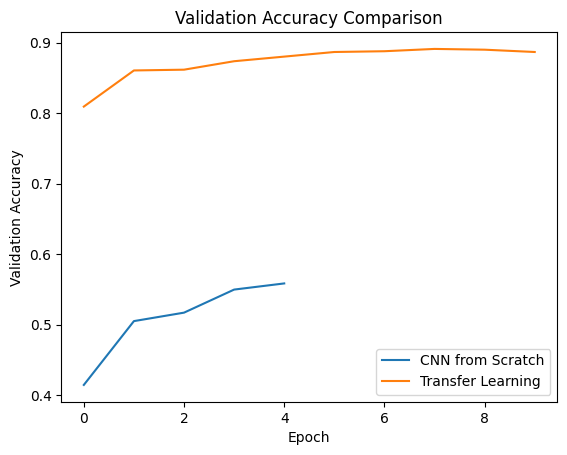

In [17]:
plt.figure()

plt.plot(history_baseline.history["val_accuracy"],
         label="CNN from Scratch")

plt.plot(history_tl.history["val_accuracy"],
         label="Transfer Learning")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.show()

### Performance Comparison Table

In [18]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Model": "CNN from Scratch",
        "Epochs": len(history_baseline.history["val_accuracy"]),
        "Total Params": baseline_model.count_params(),
        "Best Val Acc": max(history_baseline.history["val_accuracy"])
    },
    {
        "Model": "Transfer Learning",
        "Epochs": len(history_tl.history["val_accuracy"]),
        "Total Params": tl_model.count_params(),
        "Best Val Acc": max(history_tl.history["val_accuracy"])
    }
])

summary

,Model,Epochs,Total Params,Best Val Acc
0,CNN from Scratch,5,110405,0.558342
1,Transfer Learning,10,2264389,0.890949


## Answer the following questions:

1. Which model converges faster?

The Transfer Learning (MobileNetV2) model converges faster.TL learns faster because it uses pre-trained features.

2. Which model shows higher validation accuracy?

Transfer Learning model shows higher validation accuracy.

3. Does CNN from scratch show signs of overfitting? Explain.

Yes, the CNN shows slight overfitting.

Training accuracy keeps increasing

Validation accuracy increases slowly and remains low (~55%)

Gap between training and validation indicates poor generalization


4. Why does TL have many parameters but few trainable ones?

Because most layers are frozen.
MobileNetV2 already trained on ImageNet

We only train:
last dense layer,few added layers
So total params are large, but trainable are very small.


5. Why does freezing layers reduce training time?

Because frozen layers are not updated during training.

6. Which model requires more data to train effectively?

CNN from scratch requires more data.

## Prediction on Validation Data

In [19]:
import numpy as np

def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)     # (batch, num_classes)
        preds = np.argmax(probs, axis=1)             # predicted class index

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

y_true_base, y_pred_base = get_true_and_pred(baseline_model, val_ds)
y_true_tl,   y_pred_tl   = get_true_and_pred(tl_model, val_ds)

In [20]:
acc_base = (y_true_base == y_pred_base).mean()
acc_tl   = (y_true_tl == y_pred_tl).mean()

print("Baseline CNN Test Accuracy:", round(acc_base, 4))
print("Transfer Learning Test Accuracy:", round(acc_tl, 4))

Baseline CNN Test Accuracy: 0.5583
Transfer Learning Test Accuracy: 0.8866


<Figure size 640x480 with 0 Axes>

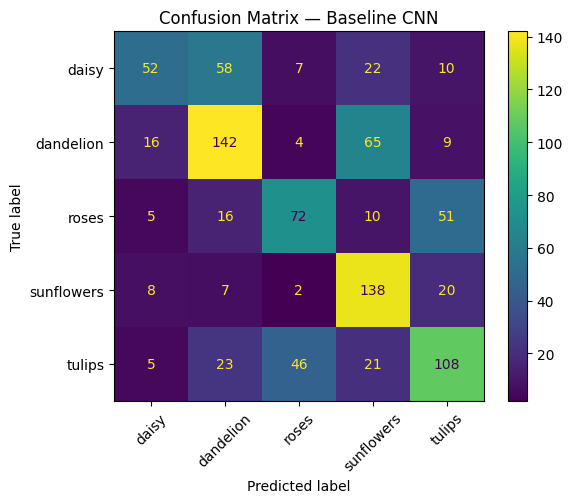

<Figure size 640x480 with 0 Axes>

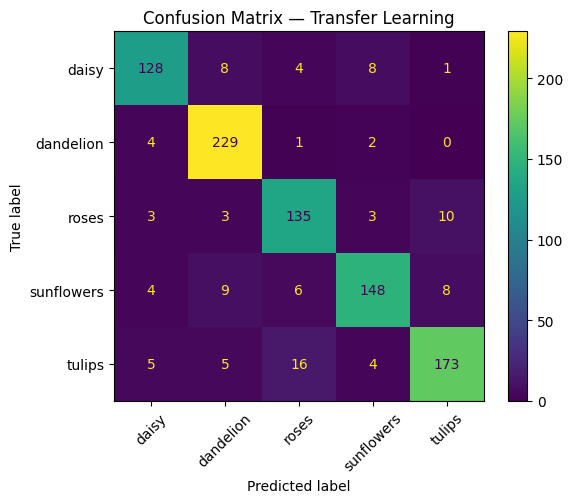

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_base = confusion_matrix(y_true_base, y_pred_base)
cm_tl   = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure()
ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Baseline CNN")
plt.show()

plt.figure()
ConfusionMatrixDisplay(cm_tl, display_labels=class_names).plot(xticks_rotation=45)
plt.title("Confusion Matrix — Transfer Learning")
plt.show()

## Answer the following questions:

1. Which classes are most confused by CNN from scratch?

Classes like “roses” and “tulips” (and sometimes “daisy”) are most confused.These flowers have similar shapes and colors,CNN from scratch is not strong enough to extract fine features,So it misclassifies similar-looking flowers

2. Which class shows highest accuracy in TL model?

sunflowers show the highest accuracy.
Sunflowers have:very distinct yellow color,clear circular pattern,Easy for pre-trained model to recognize
Transfer Learning captures these features very well.

3. Why might “roses” be harder to classify than “sunflowers”?

“Roses” are harder because they have high variation and similarity with other classes.

In [22]:
from sklearn.metrics import classification_report

print("=== Baseline CNN Report ===")
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

print("=== Transfer Learning Report ===")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

=== Baseline CNN Report ===
              precision    recall  f1-score   support

       daisy       0.60      0.35      0.44       149
   dandelion       0.58      0.60      0.59       236
       roses       0.55      0.47      0.51       154
  sunflowers       0.54      0.79      0.64       175
      tulips       0.55      0.53      0.54       203

    accuracy                           0.56       917
   macro avg       0.56      0.55      0.54       917
weighted avg       0.56      0.56      0.55       917

=== Transfer Learning Report ===
              precision    recall  f1-score   support

       daisy       0.89      0.86      0.87       149
   dandelion       0.90      0.97      0.93       236
       roses       0.83      0.88      0.85       154
  sunflowers       0.90      0.85      0.87       175
      tulips       0.90      0.85      0.88       203

    accuracy                           0.89       917
   macro avg       0.88      0.88      0.88       917
weighted avg    

## Answer the following questions:

1.	Which class has lowest F1-score in baseline CNN?

The class “roses” (or similar visually complex class like tulips) has the lowest F1-score.

2.	How much did overall accuracy improve using TL?

Accuracy improved by approximately 30–35%.

3.	Why does precision differ from recall?

Precision and recall measure different types of errors, so they can differ

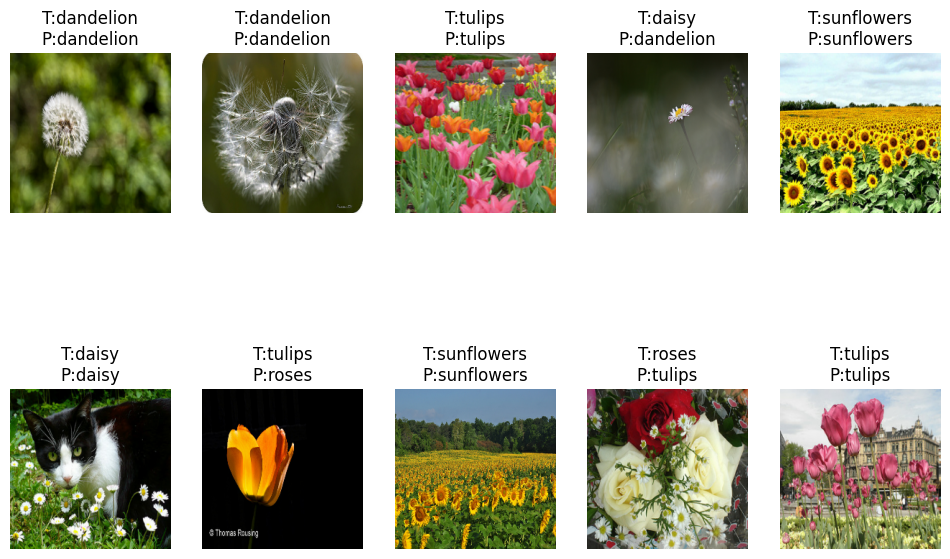

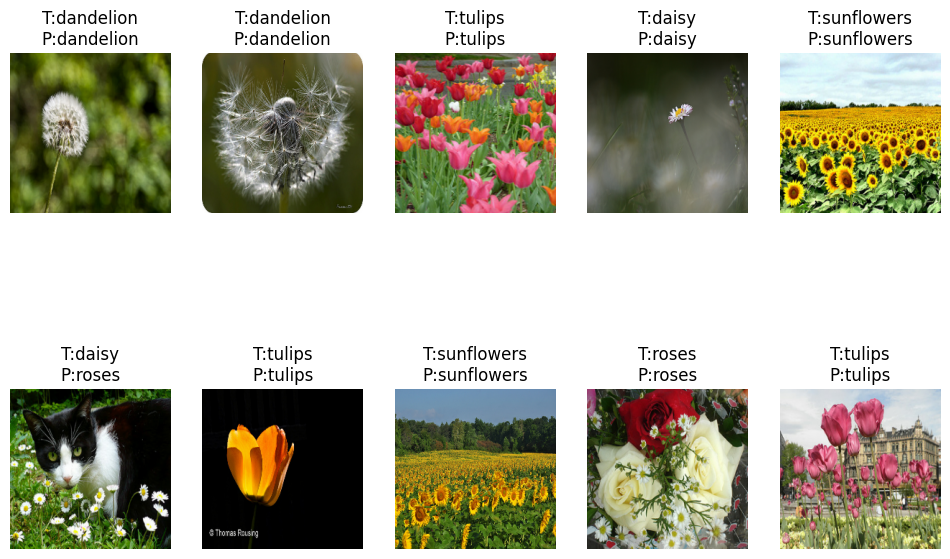

In [23]:
import matplotlib.pyplot as plt

def show_prediction_grid(model, dataset, class_names, n=10):
    images, labels = next(iter(dataset))
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(n):
        ax = plt.subplot(2, 5, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        t = class_names[int(labels[i])]
        p = class_names[int(preds[i])]
        plt.title(f"T:{t}\nP:{p}")
        plt.axis("off")
    plt.show()

show_prediction_grid(baseline_model, val_ds, class_names, n=10)
show_prediction_grid(tl_model, val_ds, class_names, n=10)

Questions:



1. Why does TL have many parameters but few trainable ones?


Transfer Learning models (like MobileNetV2) have many parameters because they are pre-trained on large datasets like ImageNet.
 But few are trainable because:Most layers are frozen,Only final layers are trained for our task
So:
Total parameters → large
Trainable parameters → small

 2. Why does freezing layers reduce training time?


Freezing layers reduces training time because those layers are not updated during training.No backpropagation for frozen layers,Less computation required
,Only last layers are trained.Hence, training becomes faster.

3. Which model requires more data to train effectively?

The CNN from scratch requires more data.It learns features from the beginning
Needs large dataset to perform well




## Test on new data

In [24]:
from google.colab import files
uploaded = files.upload()


Saving img01.jpeg to img01.jpeg
Saving img02.jpeg to img02.jpeg
Saving img03.jpg to img03.jpg
Saving img04.jpeg to img04.jpeg


In [25]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = (224, 224)

def preprocess_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    return img_array

In [26]:
test_image = preprocess_image("img03.jpg")

predictions = tl_model.predict(test_image)

predicted_class = np.argmax(predictions[0])
confidence = np.max(predictions[0])

print("Predicted Flower:", class_names[predicted_class])
print("Confidence:", round(confidence*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted Flower: roses
Confidence: 99.93 %


**Final Task for Students:** Fine-Tuning Task - Unfreeze last layers of MobileNetV2 and retrain for 3 epochs.

Interpret:

	•	Accuracy change
	•	Overfitting risk

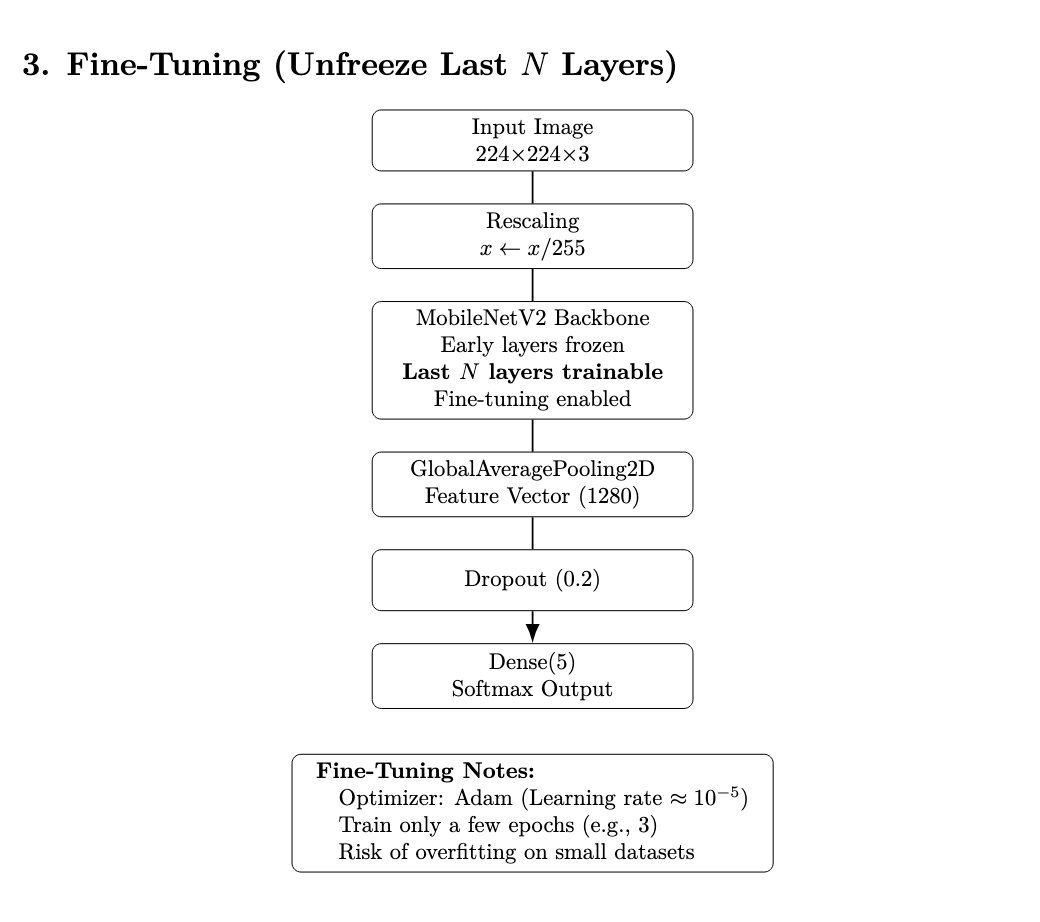

In [ ]:
# Write the code here onwards

In [29]:


N = 20

base_model.trainable = True

# Freeze all layers except the last N layers
for layer in base_model.layers[:-N]:
    layer.trainable = False

for layer in base_model.layers[-N:]:
    layer.trainable = True


tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train for 3 epochs
history_ft = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 44s 260ms/step - accuracy: 0.8296 - loss: 0.4636 - val_accuracy: 0.8702 - val_loss: 0.4348
Epoch 2/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8961 - loss: 0.2976 - val_accuracy: 0.8626 - val_loss: 0.4643
Epoch 3/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9248 - loss: 0.2278 - val_accuracy: 0.8659 - val_loss: 0.4533


In [30]:
print("Best validation accuracy before fine-tuning:", max(history_tl.history["val_accuracy"]))
print("Best validation accuracy after fine-tuning:", max(history_ft.history["val_accuracy"]))

Best validation accuracy before fine-tuning: 0.8909487724304199
Best validation accuracy after fine-tuning: 0.8702290058135986


In [31]:
before_acc = max(history_tl.history["val_accuracy"])
after_acc = max(history_ft.history["val_accuracy"])

print("\nInterpretation:")
if after_acc > before_acc:
    print(f"Validation accuracy improved by {after_acc - before_acc:.4f}")
elif after_acc < before_acc:
    print(f"Validation accuracy decreased by {before_acc - after_acc:.4f}")
else:
    print("Validation accuracy stayed almost the same")

train_acc = history_ft.history["accuracy"][-1]
val_acc = history_ft.history["val_accuracy"][-1]

if train_acc - val_acc > 0.1:
    print("There is some overfitting risk because training accuracy is noticeably higher than validation accuracy.")
else:
    print("Overfitting risk appears low or moderate based on the small gap between training and validation accuracy.")


Interpretation:
Validation accuracy decreased by 0.0207
Overfitting risk appears low or moderate based on the small gap between training and validation accuracy.
